In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [4]:
df=pd.read_csv('C:/a/ai/data/ChurnData.csv')
df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


In [5]:
# 결측치 확인
df.isna().sum()

tenure      0
age         0
address     0
income      0
ed          0
employ      0
equip       0
callcard    0
wireless    0
longmon     0
tollmon     0
equipmon    0
cardmon     0
wiremon     0
longten     0
tollten     0
cardten     0
voice       0
pager       0
internet    0
callwait    0
confer      0
ebill       0
loglong     0
logtoll     0
lninc       0
custcat     0
churn       0
dtype: int64

In [6]:
df.shape

(200, 28)

In [7]:
df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


In [8]:
# .values : 넘파이 array로 변환
# float32 : 파이토치 모델 - 기본적으로 float32타임의 텐서를 입력으로 받는다
features=df.drop('churn', axis=1).values.astype('float32')
label=df['churn'].values.astype('float32')

In [9]:
X_train, X_test, y_train, y_test=train_test_split(features, label, test_size=0.2, random_state=1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(160, 27) (40, 27) (160,) (40,)


In [10]:
# StandardScaler(표준화)/ MinMaxScaler(정규화)
# 평균0, 표준편차 1     /  최소 0, 최대 1
# 딥러닝에서 많이 쓰임  / 이미지 처리

In [11]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [12]:
X_train_tensor=torch.FloatTensor(X_train)
X_test_tensor=torch.FloatTensor(X_test)

In [13]:
# 파이토치에서 결과낼 때 [Batch_size, 1]
# 모델 출력과 타켓 데이터 형식을 일치시키기 위해 [Batch_size,1] 형태로 재구성
y_train_tensor=torch.FloatTensor(y_train).view(-1,1)
y_test_tensor=torch.FloatTensor(y_test).view(-1,1)
print(y_train_tensor.shape, y_test_tensor.shape)

torch.Size([160, 1]) torch.Size([40, 1])


In [14]:
# 사용자 정의 로지스틱 회귀 모델 정의
# 데이터 처리 시 2의 거듭제곱단위로 처리하는 게 연산 효율이 좋다(8,16,32,64,128,,,)
class LogisticReg(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        # 입력층 -> 은닉층(32노드) -> 출력층(1노드)
        # 첫번째 선형레이어 정의
        self.linear1=nn.Linear(in_dim, 32)
        self.linear2=nn.Linear(32,1)
        # 선형레이어 쌓으면 -> 직선형태만 판단 (relu는 비선형성 더해줌)
        self.relu=nn.ReLU()
        # 모델의 마지막단계 out에 넣기
        self.sigmoid=nn.Sigmoid()

    def forward(self, x):
        # 첫번째 선형레이어 통과후, ReLU활성화 함수 적
        x=self.relu(self.linear1(x))
        # 두번째 선형레이어 통과후, 시그모이드활성화 함수
        out=self.sigmoid(self.linear2(x))
        return out

In [15]:
model=LogisticReg(X_train.shape[1])
model
# model 객체 생성 후, w,b 무작위 숫자로 생성됨

LogisticReg(
  (linear1): Linear(in_features=27, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [16]:
bceloss1=nn.BCELoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

In [17]:
# TensorDataset 학습데이터넷 생성
# 학습 시 문제 하나보고 정답하나 확인하는 과정
train_ds=TensorDataset(X_train_tensor, y_train_tensor)
# 학습데이터 -> DataLoader()
train_loader=DataLoader(train_ds, batch_size=64, shuffle=True)

In [18]:
loss1=[]
num_epochs=50

for epoch in range(num_epochs):
    for x,y in train_loader:
        # 모델에 입력(문제) 데이터를 넣고
        yhat=model(x)
        loss=bceloss1(yhat,y) 

        # 기울기 초기화
        optimizer.zero_grad()
        loss.backward()
        # 계산된 기울기 사용해 모델 파라미터 update
        optimizer.step()
       
    print("epoch: {}, loss:{}".format(epoch+1, loss.item()))
    loss1.append(loss.item())

epoch: 1, loss:0.6711224317550659
epoch: 2, loss:0.6773368120193481
epoch: 3, loss:0.6579038500785828
epoch: 4, loss:0.6456141471862793
epoch: 5, loss:0.6288430690765381
epoch: 6, loss:0.6202952265739441
epoch: 7, loss:0.6165279150009155
epoch: 8, loss:0.5182439088821411
epoch: 9, loss:0.6140000820159912
epoch: 10, loss:0.647121250629425
epoch: 11, loss:0.5694542527198792
epoch: 12, loss:0.5841503143310547
epoch: 13, loss:0.597785234451294
epoch: 14, loss:0.5660795569419861
epoch: 15, loss:0.5275943875312805
epoch: 16, loss:0.5838884711265564
epoch: 17, loss:0.5530716776847839
epoch: 18, loss:0.5331321358680725
epoch: 19, loss:0.5583465099334717
epoch: 20, loss:0.4768596589565277
epoch: 21, loss:0.5939733982086182
epoch: 22, loss:0.5068580508232117
epoch: 23, loss:0.4221390187740326
epoch: 24, loss:0.44900137186050415
epoch: 25, loss:0.4567244052886963
epoch: 26, loss:0.5084533095359802
epoch: 27, loss:0.5480722188949585
epoch: 28, loss:0.4514053463935852
epoch: 29, loss:0.412438571453

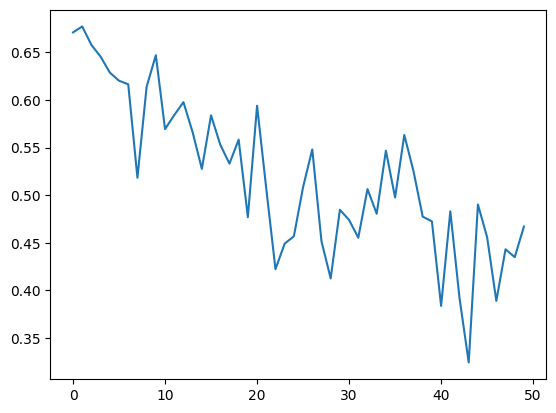

In [19]:
plt.plot(loss1)

In [20]:
# 기울기에 영향을 주지 않게 
# detach 텐서 분리
# numpy 배열 변환
y_pred=model(X_test_tensor).detach().numpy() > 0.5
y_pred

array([[ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True]])

In [21]:
# true의 개수를 다 더함(정답과 예측값을 비교해서 같으면 1, 다르면 0)
sum(y_test==y_pred.flatten())/len(y_test)

# 정확도 0.775 => 100명중 78명의 이탈여부를 맞혔다.

np.float64(0.8)

In [22]:
y_pred.flatten()

array([ True,  True, False, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
        True,  True, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False,  True])

In [23]:
y_test

array([1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 1.], dtype=float32)